# α-Helix Secondary Structure — End-to-End Pipeline
### Two-state HMM → Forward–Backward → BayesFlow → real-protein evaluation

This notebook runs **every step of the project in order, with diagrams**. It reuses the
project modules (`simulate.py`, `forward_backward.py`, `train_bayesflow.py`,
`insulin_eval.py`) so the model is defined in exactly **one** place.

**How to run:** open this notebook from the `restart/` folder and choose
*Kernel → Restart & Run All*. Heavy steps use a small demo scale for interactivity;
the full-scale results are shown from the saved runs.

| Step | What happens |
|------|--------------|
| 0 | The statistical model — a two-state HMM |
| 1 | Simulator — generate chains matched to real lengths |
| 2 | Forward–Backward — exact per-residue P(helix) targets |
| 3 | BayesFlow — amortized neural posterior (windowing + encoding) |
| 4 | Insulin & real-protein evaluation |
| 5 | Comparison & results |

In [1]:
import os, sys
sys.path.insert(0, "src")                        # the pipeline modules live in src/
os.environ.setdefault("KERAS_BACKEND", "torch")   # must precede keras/bayesflow import
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from sklearn.metrics import roc_auc_score

TEAL, DEEP = "#1D9E75", "#0F6E56"
rng = np.random.default_rng(0)
print("environment ready — cwd:", os.getcwd())

environment ready — cwd: D:\SBI\restart


## Step 0 — The statistical model: a two-state HMM

Two hidden states, **helix** and **other**. Every chain starts in *other*. The state path is a
first-order Markov chain; each state emits an amino acid from its own table. All numbers come
from `simulate.py` (single source of truth).

> **Prior & likelihood.** No parameters are inferred — everything is fixed. The **prior** is the
> induced distribution over hidden state paths **p(z₁:T)** given `startprob = [0,1]` and the
> transition matrix; the **likelihood** is the emission table. In the amortized setup, the
> effective prior over θ is the marginal of `logit γ` induced by simulating chains and running
> Forward–Backward — which is exactly what SBC ranks against (Step 6).

In [2]:
from simulate import AA, START_PROB, TRANS, EMIT, H, O, N_AA

print("Amino-acid alphabet:", "".join(AA))
print("\nStart distribution [helix, other]:", START_PROB, " -> always starts in 'other'")
print("\nTransition matrix (row = current state):")
print("             ->helix  ->other")
for name, i in [("helix", H), ("other", O)]:
    print(f"  from {name:5s}   {TRANS[i,H]:.2f}     {TRANS[i,O]:.2f}")
print("\nEmission probabilities (%):")
print("  AA    " + " ".join(f"{a:>3}" for a in AA))
for name, row in zip(["helix", "other"], EMIT):
    print(f"  {name:5s} " + " ".join(f"{int(round(v*100)):>3}" for v in row))

Amino-acid alphabet: ARNDCEQGHILKMFPSTWYV

Start distribution [helix, other]: [0. 1.]  -> always starts in 'other'

Transition matrix (row = current state):
             ->helix  ->other
  from helix   0.90     0.10
  from other   0.05     0.95

Emission probabilities (%):
  AA      A   R   N   D   C   E   Q   G   H   I   L   K   M   F   P   S   T   W   Y   V
  helix  12   6   3   5   1   9   5   4   2   7  12   6   3   4   2   5   4   1   3   6
  other   6   5   5   6   2   5   3   9   3   5   8   6   2   4   6   7   6   1   4   7


**Diagram — the two-state HMM and its emission tables:**

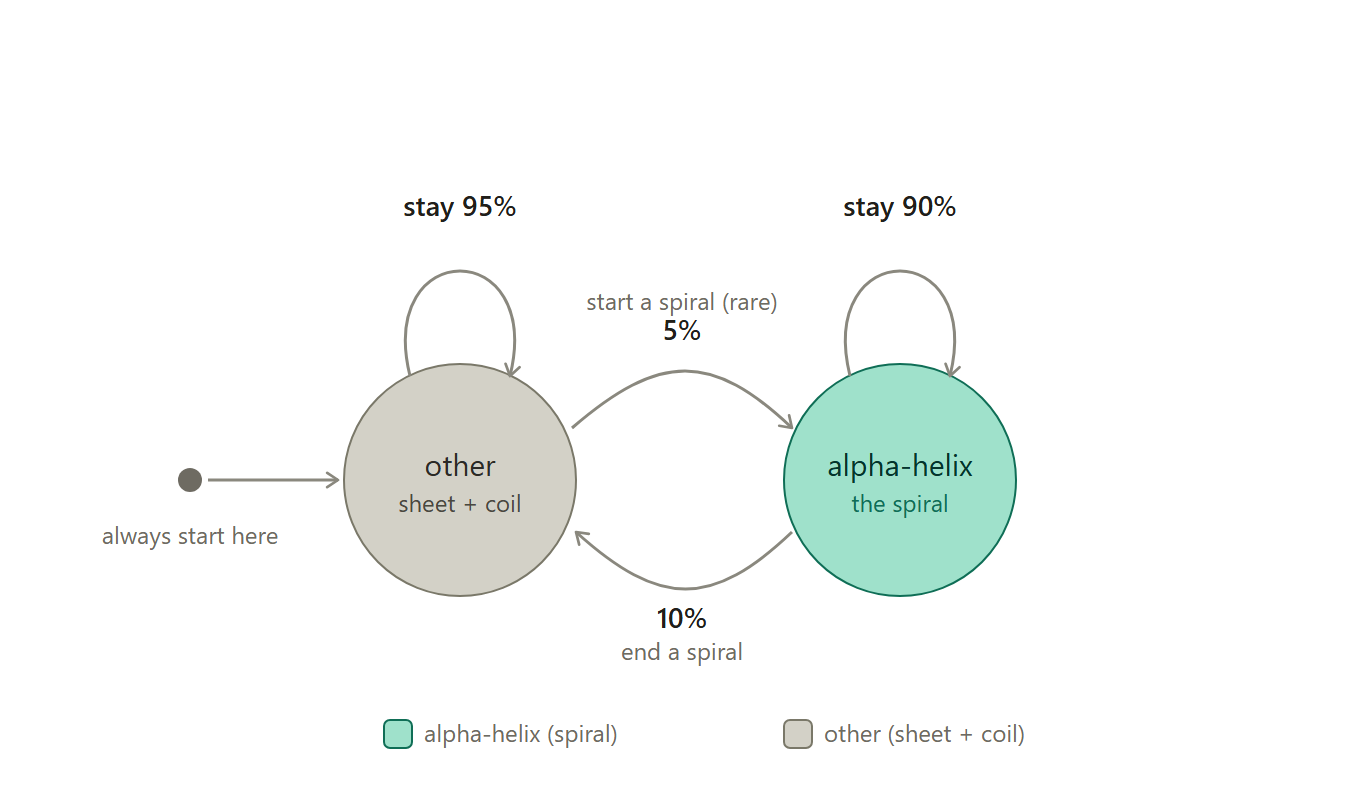

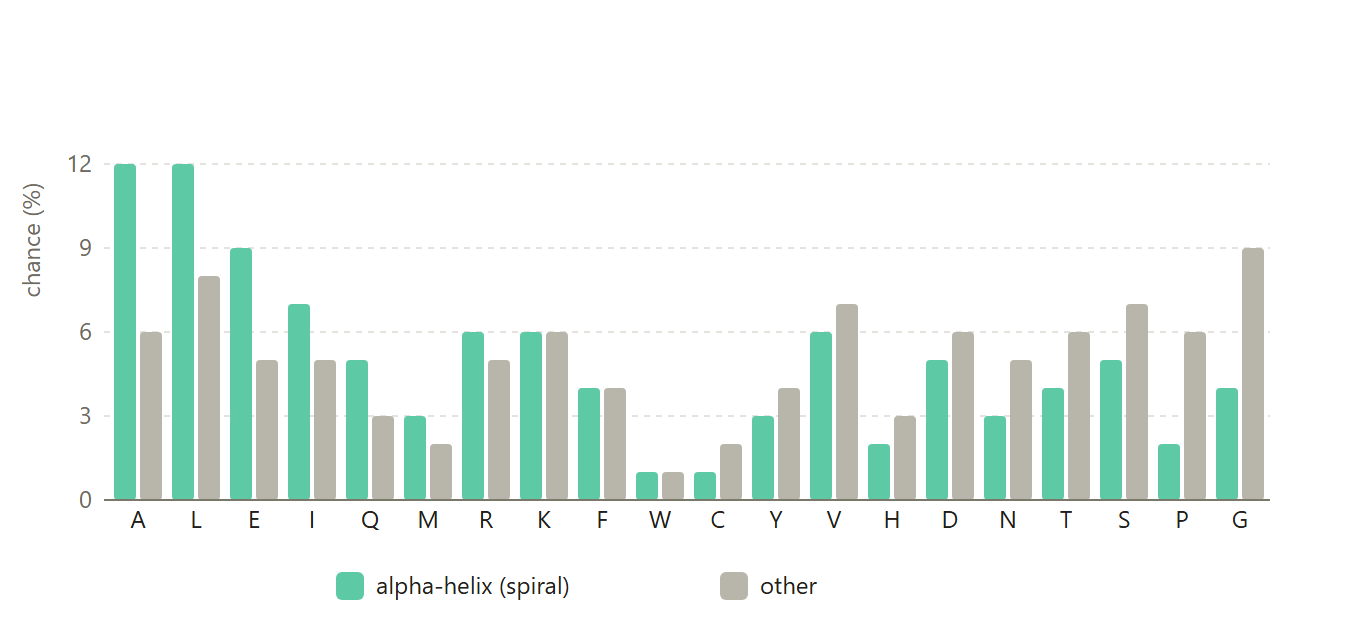

In [3]:
display(Image(filename="../hmm_explainer/1_two_state_hmm.png"))
display(Image(filename="../hmm_explainer/2_emission_probabilities.png"))

## Step 1 — Simulator

Generate amino-acid chains from the HMM. Chain **lengths are sampled from the real PISCES
length distribution**, so the synthetic set mirrors real proteins in length.

In [4]:
from simulate import simulate_chain, load_lengths

# one example chain
st, seq, n_h = simulate_chain(60, rng)
print("hidden states:", st)
print("amino acids  :", seq)

# a demo set (small, for interactivity; the real run uses 100,000)
gt_lengths = load_lengths("../archive/2018-06-06-pdb-intersect-pisces.csv")
N_DEMO = 4000
lengths = rng.choice(gt_lengths, size=N_DEMO, replace=True)
chains = [simulate_chain(int(L), rng) for L in lengths]
hf = sum(c[2] for c in chains) / sum(len(c[0]) for c in chains)
print(f"\nsimulated {N_DEMO} chains; helix fraction {hf:.3f} (stationary theory 0.333)")

hidden states: OOHHHOOOOOOHHHHHHHHHHHHHHHOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOO
amino acids  : GDALEFDVGRKYGVIGLVVHFIIFGMPVNPYVATVVNVWTICSYELIVAPKAPASLYRTR



simulated 4000 chains; helix fraction 0.322 (stationary theory 0.333)


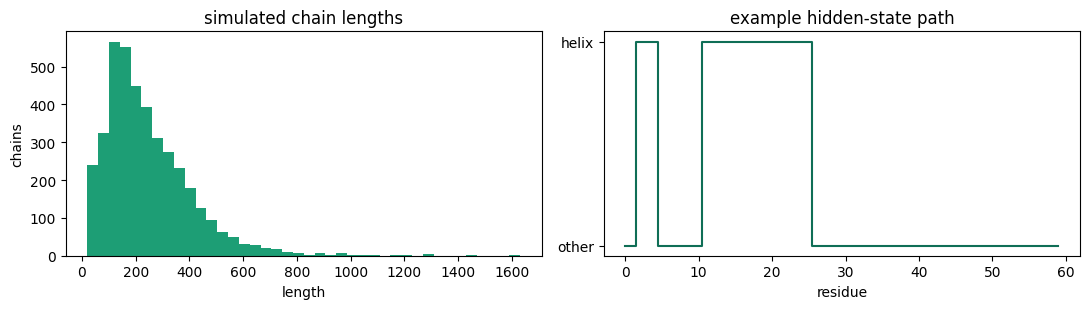

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(lengths, bins=40, color=TEAL)
ax[0].set(title="simulated chain lengths", xlabel="length", ylabel="chains")
s0 = np.array([1 if c == 'H' else 0 for c in st])
ax[1].step(range(len(s0)), s0, where="mid", color=DEEP)
ax[1].set(title="example hidden-state path", xlabel="residue", yticks=[0, 1])
ax[1].set_yticklabels(["other", "helix"])
plt.tight_layout(); plt.show()

## Step 2 — Forward–Backward (exact per-residue posterior)

Given a sequence, `hmmlearn`'s Forward–Backward gives the exact **P(helix | whole chain)** for
every residue. These are the "answer key" targets that BayesFlow will learn to reproduce.

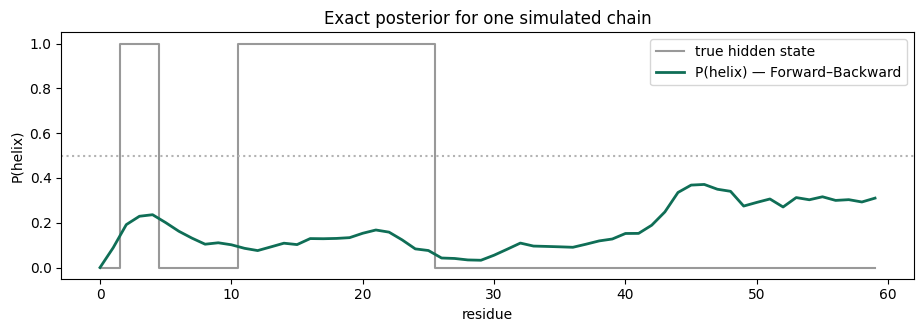

residue-0 P(helix) = 0.0  (start rule -> exactly 0)


In [6]:
from forward_backward import build_model, fb_posterior, encode

fb_model = build_model()
p_helix, loglik = fb_posterior(seq, fb_model)
true = np.array([1 if c == 'H' else 0 for c in st])

plt.figure(figsize=(11, 3.2))
plt.step(range(len(true)), true, where="mid", color="0.6", label="true hidden state")
plt.plot(p_helix, color=DEEP, lw=2, label="P(helix) — Forward–Backward")
plt.axhline(0.5, ls=":", color="0.7"); plt.ylim(-.05, 1.05)
plt.xlabel("residue"); plt.ylabel("P(helix)"); plt.legend()
plt.title("Exact posterior for one simulated chain"); plt.show()
print("residue-0 P(helix) =", round(float(p_helix[0]), 3), " (start rule -> exactly 0)")

In [7]:
# validate the exact posterior against the KNOWN hidden states over a subset
pa, ta = [], []
for st_i, seq_i, _ in chains[:1000]:
    p, _ = fb_posterior(seq_i, fb_model); pa.append(p)
    ta.append((np.frombuffer(st_i.encode(), np.uint8) == ord('H')).astype(int))
pa = np.concatenate(pa); ta = np.concatenate(ta)
print(f"mean P(helix) {pa.mean():.3f}  vs  true helix fraction {ta.mean():.3f}  (well calibrated)")
print(f"AUC vs true hidden state {roc_auc_score(ta, pa):.3f}  (Bayes-optimal ceiling ~0.79)")

mean P(helix) 0.323  vs  true helix fraction 0.322  (well calibrated)
AUC vs true hidden state 0.792  (Bayes-optimal ceiling ~0.79)


## Step 3 — BayesFlow amortized posterior

A normalizing flow needs a **fixed-size** input, but chains vary in length. So we predict **one
residue at a time** from a fixed **31-residue window** (±15), slid along the chain. The window is
**one-hot encoded** as 31 × 21 channels (20 amino acids + 1 padding for chain ends). Because the
window is only local, the target stays uncertain → a genuine posterior (mean ± std).

> **Why SBI when the likelihood is tractable?** Because **the tractability is the point.** This is
> a benchmark where the exact posterior is *known*, which is the only way to *verify* that an
> amortized neural posterior is faithful. In a real SBI problem you could never run this check.

> **The mismatch we own:** θ is γ computed by FB from the **whole chain**, but we condition on a
> **local window**. The cell below shows why that's harmless — and why `r = 0.999` is *expected*,
> not evidence of leakage.

In [8]:
# Why is a +/-15 window enough? The HMM mixes fast.
ev = np.sort(np.abs(np.linalg.eigvals(TRANS.T)))[::-1]
lam2 = ev[1]
print(f"transition matrix eigenvalues: {np.round(ev, 4)}")
print(f"second eigenvalue  lambda2 = 1 - 0.10 - 0.05 = {lam2:.2f}\n")
for k in (5, 10, 15, 20):
    print(f"  influence at +/-{k:2d} residues:  lambda2^{k} = {lam2**k:.3f}")
print("\n-> beyond +/-15 residues, <10% of the information remains outside the window.")

transition matrix eigenvalues: [1.   0.85]
second eigenvalue  lambda2 = 1 - 0.10 - 0.05 = 0.85

  influence at +/- 5 residues:  lambda2^5 = 0.444
  influence at +/-10 residues:  lambda2^10 = 0.197
  influence at +/-15 residues:  lambda2^15 = 0.087
  influence at +/-20 residues:  lambda2^20 = 0.039

-> beyond +/-15 residues, <10% of the information remains outside the window.


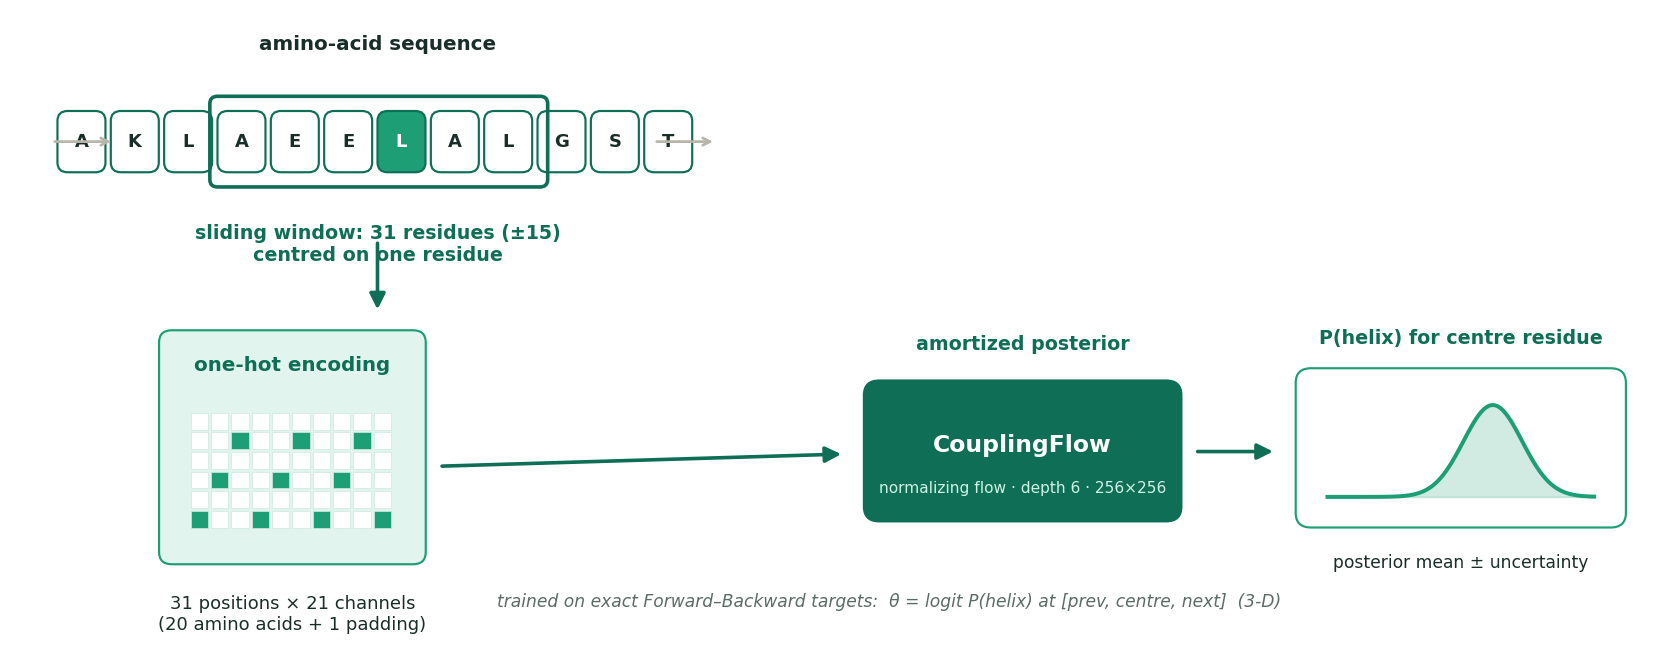

one window per residue -> shape (L, WINDOW, channels) = (60, 31, 21)
WINDOW = 31 residues,  channels = 21 (20 amino acids + 1 padding)


In [9]:
display(Image(filename="figures/bayesflow_window_schematic.png"))

from train_bayesflow import windows_for_sequence, WINDOW, N_CH, predict_helix
Wex = windows_for_sequence(encode(seq))
print(f"one window per residue -> shape (L, WINDOW, channels) = {Wex.shape}")
print(f"WINDOW = {WINDOW} residues,  channels = {N_CH} (20 amino acids + 1 padding)")

Load the trained posterior and compare it to exact FB on the example chain.
*(To retrain from scratch: `python train_bayesflow.py` — 15,000 chains, 300,000 windows, 30 epochs.)*

INFO:bayesflow:Using backend 'torch'


When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


C:\Users\MUNISH\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling: 100%|██████████| 1/1 [00:00<00:00,  8.44batch/s]

Sampling: 100%|██████████| 1/1 [00:00<00:00,  8.39batch/s]

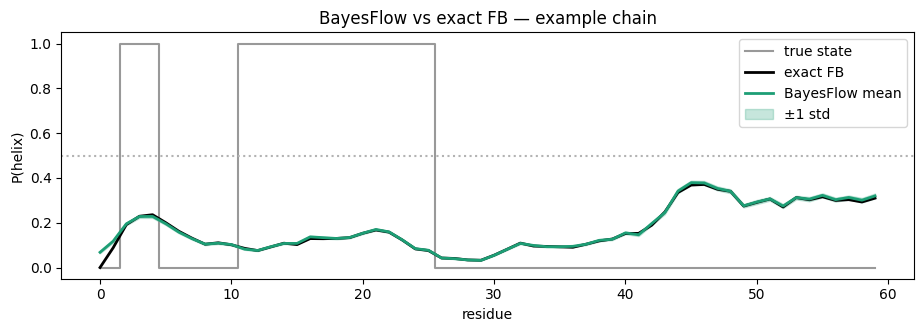

In [10]:
import bayesflow as bf     # registers serializable classes for loading
import keras
approx = keras.saving.load_model("bayesflow_posterior.keras")

mean, std = predict_helix(approx, encode(seq), num_samples=200)

plt.figure(figsize=(11, 3.2))
plt.step(range(len(true)), true, where="mid", color="0.6", label="true state")
plt.plot(p_helix, "k-", lw=2, label="exact FB")
plt.plot(mean, color=TEAL, lw=2, label="BayesFlow mean")
plt.fill_between(range(len(mean)), np.clip(mean - std, 0, 1), np.clip(mean + std, 0, 1),
                 color=TEAL, alpha=0.25, label="±1 std")
plt.axhline(0.5, ls=":", color="0.7"); plt.ylim(-.05, 1.05)
plt.xlabel("residue"); plt.ylabel("P(helix)"); plt.legend()
plt.title("BayesFlow vs exact FB — example chain"); plt.show()

**Validation on held-out simulated chains (full 15k-chain run):** correlation 0.999, MAE 0.007.

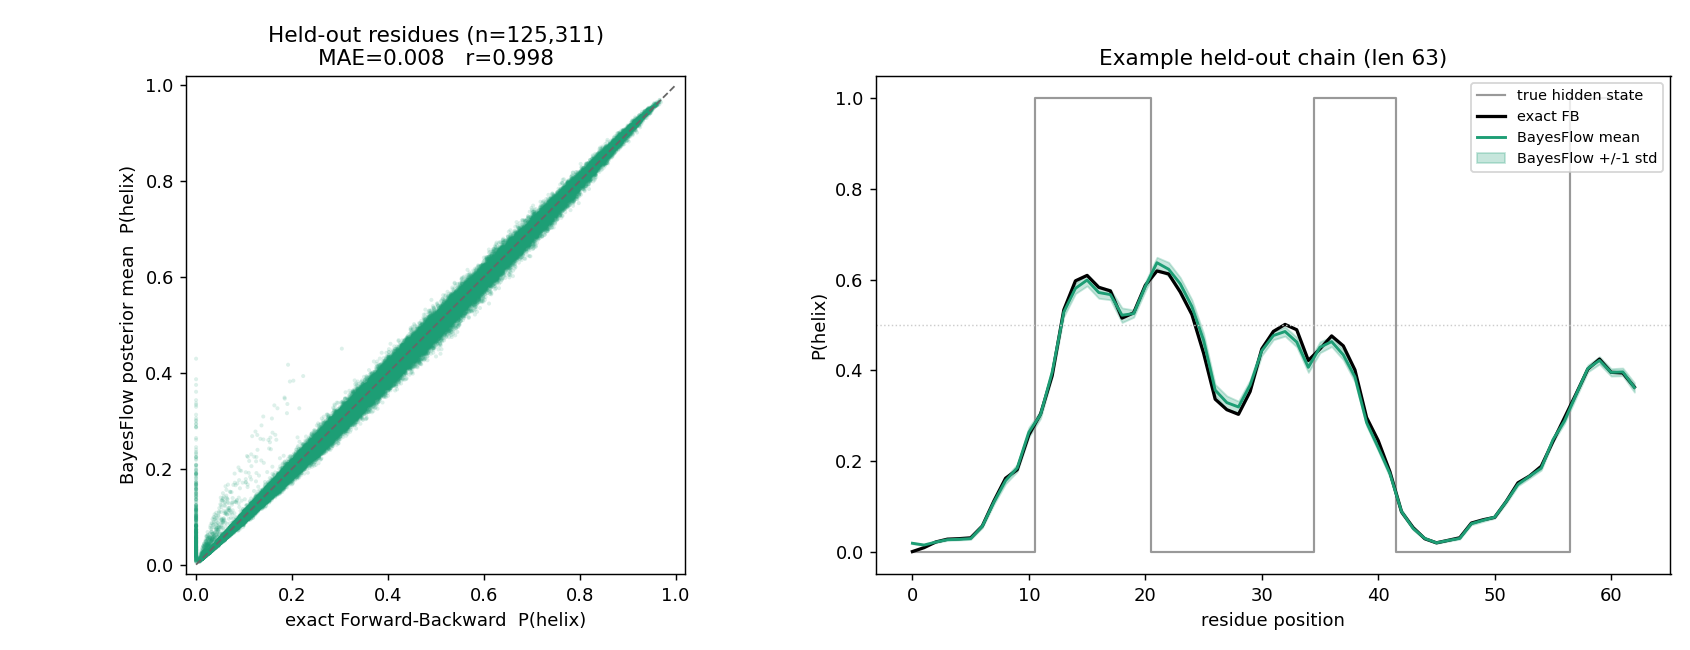

In [11]:
display(Image(filename="figures/validation_figure.png"))

## Step 4 — Insulin & real-protein evaluation

The model trained **only on simulated data**, so real proteins are genuinely held out (no leakage).
We use **wild-type** human insulin (`1MSO`) — an earlier version used `1A7F`, which is a *mutant*
(B16 Tyr→Glu, B24 Phe→Gly, des-B30) whose sparse A-chain annotation inflated its A-chain AUC.
Scored against the strict `sst8` H-only helix labels.

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling: 100%|██████████| 1/1 [00:00<00:00, 31.46batch/s]

1MSO chain A (len 21, helix 12): BayesFlow AUC=0.519   FB AUC=0.509


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling: 100%|██████████| 1/1 [00:00<00:00, 34.43batch/s]

...

Sampling: 100%|██████████| 1/1 [00:00<00:00, 34.74batch/s]

1MSO chain B (len 30, helix 11): BayesFlow AUC=0.981   FB AUC=0.986


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling: 100%|██████████| 1/1 [00:00<00:00, 33.54batch/s]

1MSO chain D (len 30, helix 11): BayesFlow AUC=0.981   FB AUC=0.986


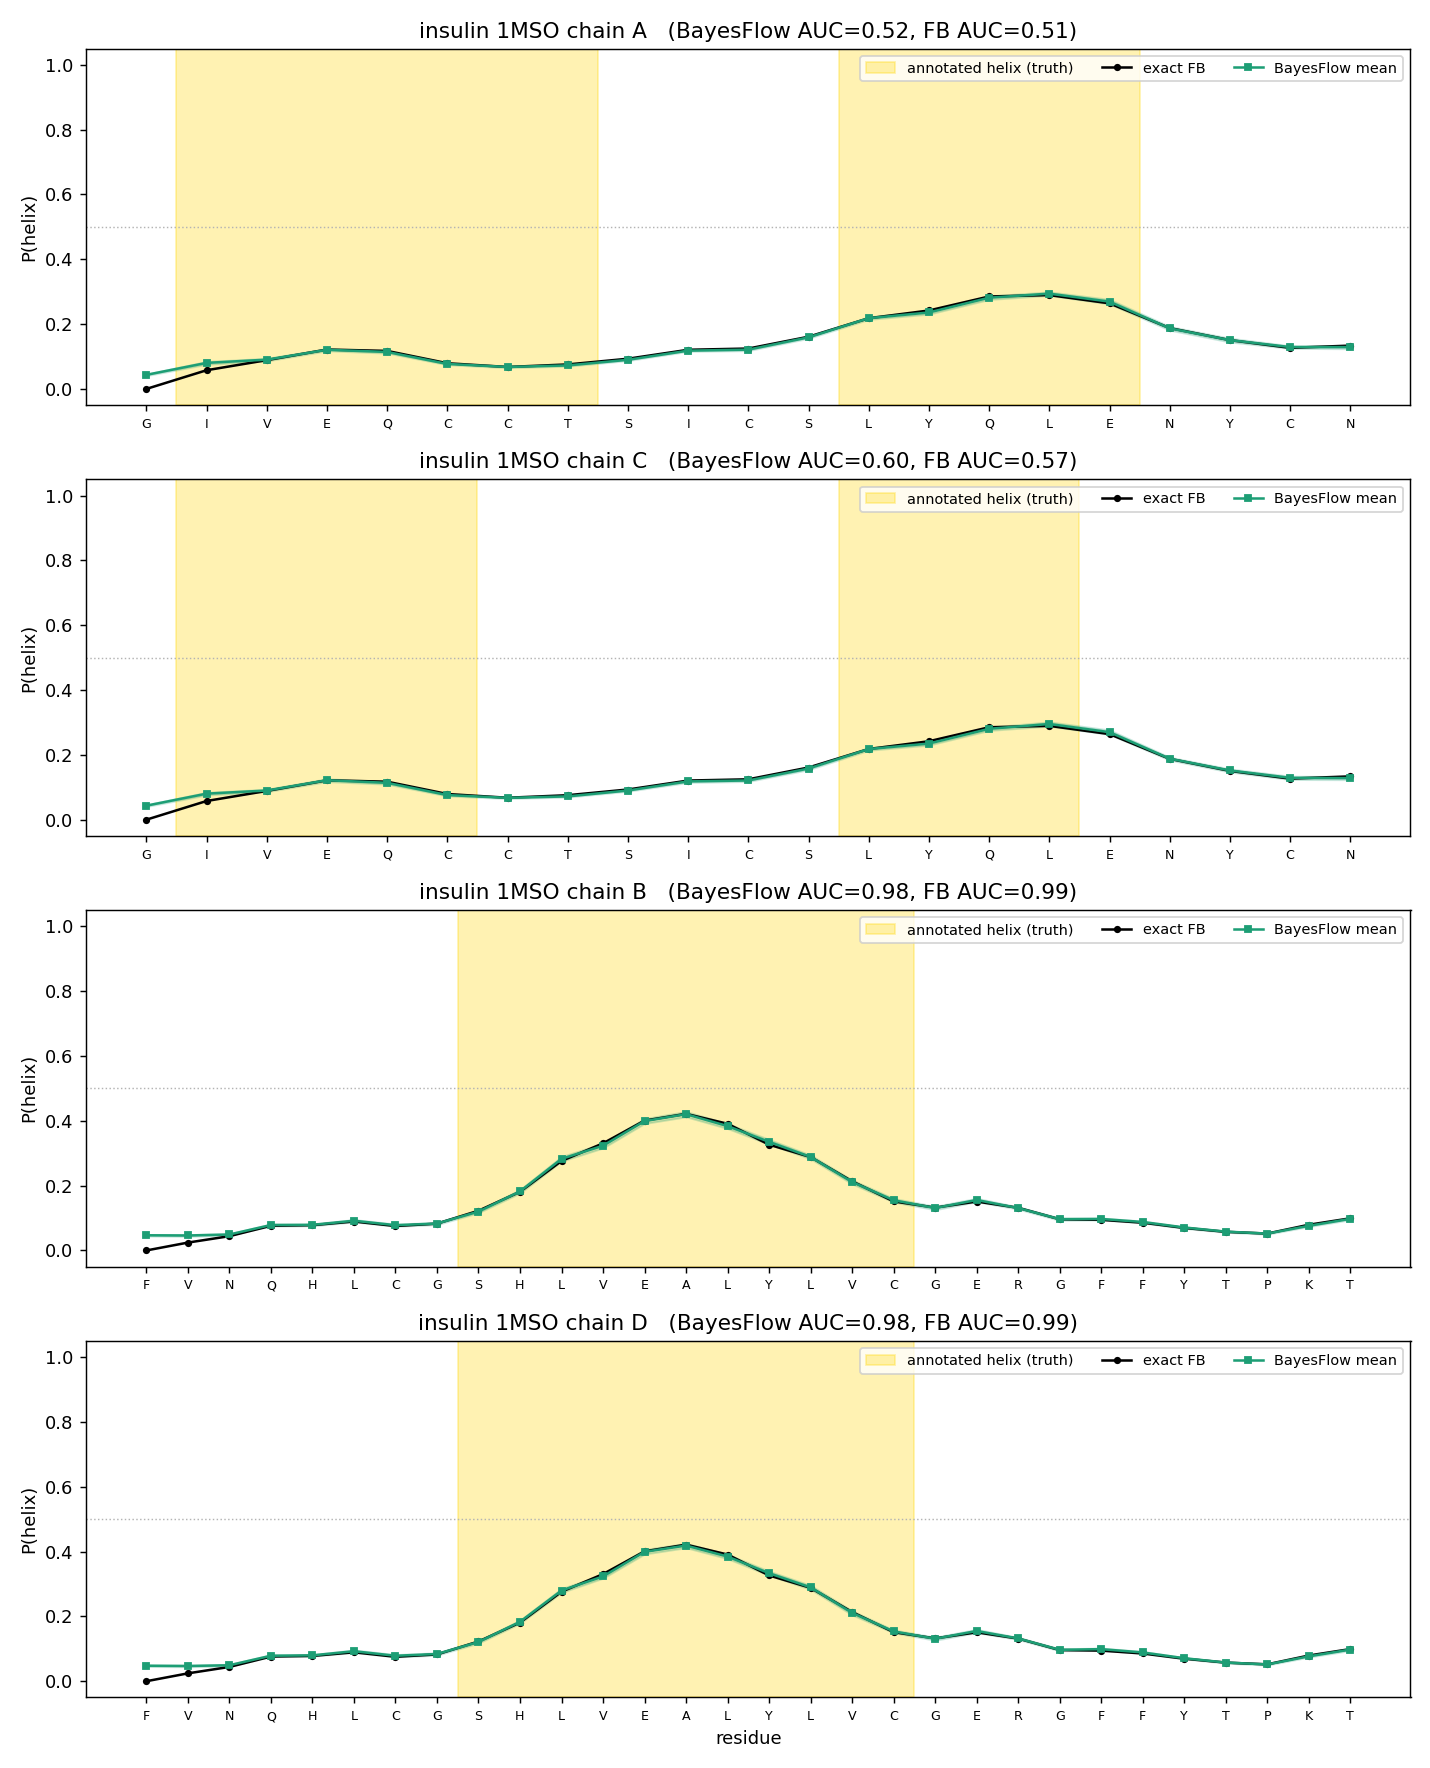

In [12]:
from insulin_eval import fetch_chains

for code_, seqi, sst8 in fetch_chains("1MSO"):
    obs = encode(seqi)
    ti = np.array([1 if c == 'H' else 0 for c in sst8], dtype=int)
    bfp, _ = predict_helix(approx, obs, num_samples=300)
    fbp, _ = fb_posterior(seqi, fb_model)
    print(f"1MSO chain {code_} (len {len(seqi):>2}, helix {int(ti.sum()):>2}): "
          f"BayesFlow AUC={roc_auc_score(ti, bfp):.3f}   FB AUC={roc_auc_score(ti, fbp):.3f}")

# 1MSO is a dimer: chains A,C are A-chains; B,D are B-chains.
display(Image(filename="figures/insulin_1MSO.png"))

The **B-chain** helix is propensity-driven (L, V, E, A) → recovered (**AUC 0.98**). The **A-chain**
helix is **disulfide-stabilised and cysteine-rich**, and C is helix-*disfavouring* in the emission
table → the model predicts "not helix" exactly where the helix is (**AUC 0.52, chance**). A
sequence-only HMM cannot see 3-D disulfide bonds. (Only 2–4 chains — illustrative, not a benchmark.)

**All real PISCES proteins** (full run: `python eval_real.py --limit 0`) — 8,994 chains, per-chain
AUC 0.754, BayesFlow = exact FB.

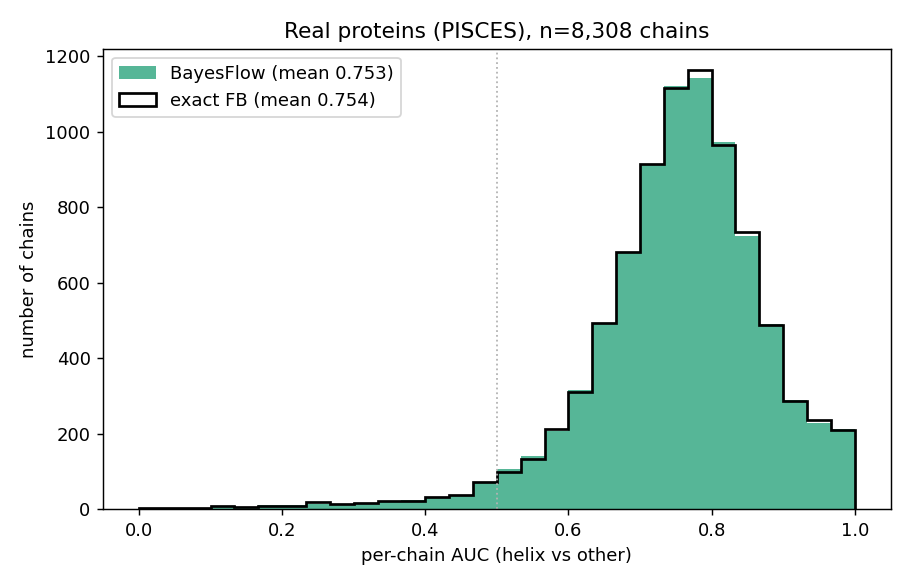

In [13]:
display(Image(filename="figures/real_eval_auc_hist.png"))

## Step 5 — Comparison & results

BayesFlow reproduces exact Forward–Backward in **every** setting (faithful amortization). Scored
against a **majority-class baseline**: accuracy@0.5 only beats the baseline on the calibrated
(simulated / pooled real) settings — on insulin it ties or falls below it, so **AUC is the fair
metric**. (`python compare_metrics.py`, `python emission_check.py`.)

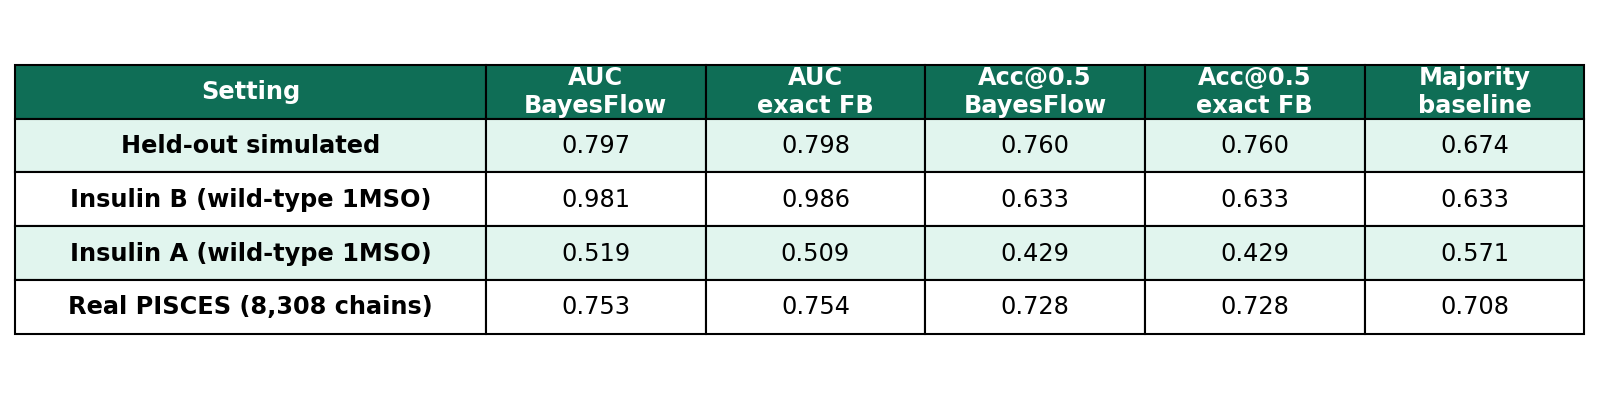

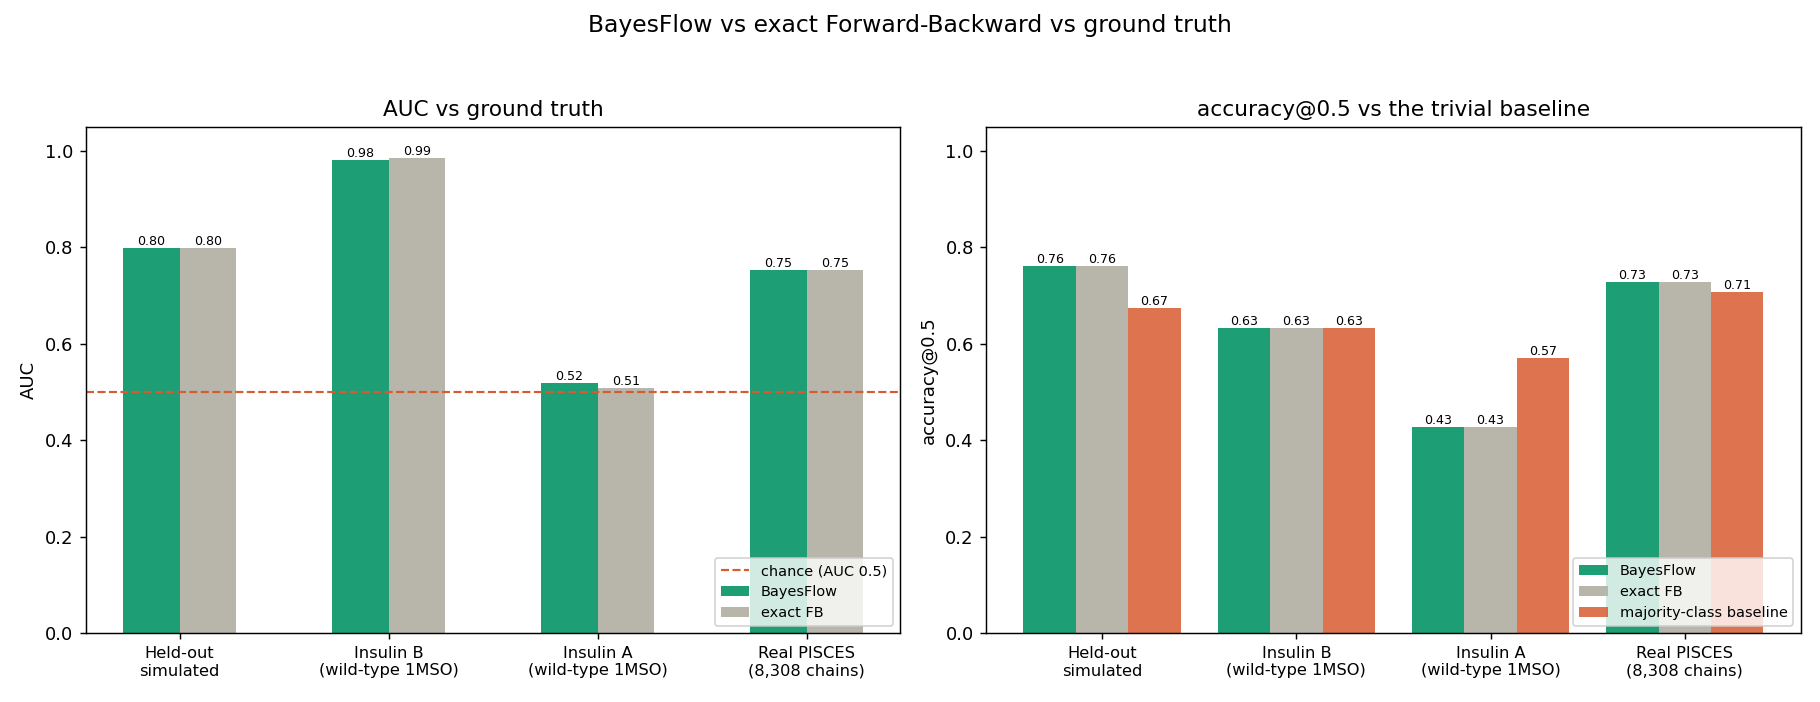

In [14]:
display(Image(filename="figures/comparison_table.png"))
display(Image(filename="figures/comparison.png"))

**Are the emission tables realistic?** We measure the empirical `P(amino acid | DSSP H vs non-H)`
from real PISCES chains and compare to the tables the model was handed — computed live below.

In [15]:
from emission_check import empirical_emissions

emp = empirical_emissions()
for k, name in enumerate(["helix", "other"]):
    r = np.corrcoef(EMIT[k], emp[k])[0, 1]
    md_ = np.abs(EMIT[k] - emp[k]).max() * 100
    print(f"{name:>6}: model vs real  r = {r:.3f}   max deviation = {md_:.1f} pp")

x = np.arange(len(AA)); w = 0.38
fig, ax = plt.subplots(2, 1, figsize=(12, 5.6), sharex=True)
for k, name in enumerate(["α-helix state", "other state"]):
    ax[k].bar(x - w/2, EMIT[k]*100, w, label="model (given)", color=TEAL)
    ax[k].bar(x + w/2, emp[k]*100, w, label="real (PISCES)", color="#B8B5AA")
    ax[k].set(ylabel="P(aa | state) %", title=name); ax[k].legend(fontsize=8)
ax[1].set_xticks(x); ax[1].set_xticklabels(AA); ax[1].set_xlabel("amino acid")
plt.tight_layout(); plt.show()

 helix: model vs real  r = 0.992   max deviation = 0.9 pp
 other: model vs real  r = 0.982   max deviation = 0.8 pp


C:\Users\MUNISH\AppData\Local\Temp\ipykernel_11136\2825782696.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


## Step 6 — SBI diagnostics (computed live)

Predictive metrics say the estimate is *useful*; these say whether the **posterior** is honest.
This is the SBI-specific evidence: **convergence**, **simulation-based calibration (SBC)**,
**recovery** and **posterior contraction** — all on held-out chains.

In [16]:
import bayesflow as bf
from train_bayesflow import load_chains, total_chains, build_training_data
from diagnostics import parse_loss_curve

# --- convergence: the loss curve of the run that produced this model ---
losses = parse_loss_curve()
if losses:
    plt.figure(figsize=(7, 3.4))
    plt.plot(range(1, len(losses)+1), losses, "-o", ms=3, color=DEEP, lw=1.8)
    plt.xlabel("epoch"); plt.ylabel("training loss"); plt.grid(alpha=0.25)
    plt.title(f"Convergence — {len(losses)} epochs ({losses[0]:.2f} → {losses[-1]:.2f})")
    plt.tight_layout(); plt.show()

# --- build a held-out diagnostic set (tail block, never trained on) ---
total = total_chains()
vidx = list(range(total - 300, total))
tri, _ = load_chains(vidx)
dchains = [tri[i] for i in vidx]
dd = build_training_data(dchains, 1200, np.random.default_rng(11))
th = np.asarray(dd["theta"], np.float32)
dr = np.asarray(approx.sample(num_samples=200, conditions={"cond": dd["cond"]})["theta"], np.float32)
print("diagnostic set:", th.shape, " draws:", dr.shape)

C:\Users\MUNISH\AppData\Local\Temp\ipykernel_11136\635449116.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling: 100%|██████████| 1/1 [00:00<00:00, 20.60batch/s]

diagnostic set: (1200, 3)  draws: (1200, 200, 3)


In [17]:
# --- SBC: is the rank of the true theta uniform among posterior draws? ---
names = [r"logit $\gamma$ (prev)", r"logit $\gamma$ (centre)", r"logit $\gamma$ (next)"]
fig = bf.diagnostics.calibration_ecdf(dr, th, variable_names=names, difference=True)
plt.show()

# --- numeric summaries ---
pm, ps = dr.mean(1), dr.std(1)
z = (pm - th) / np.maximum(ps, 1e-8)
contraction = 1.0 - (ps.mean(0)**2) / (th.std(0)**2)
print("dim      bias      mean|z|   contraction   (calibrated: |z|~0.80)")
for i, n in enumerate(["prev", "centre", "next"]):
    print(f"{n:>6}  {(pm[:,i]-th[:,i]).mean():+.4f}    {np.abs(z[:,i]).mean():.2f}      {contraction[i]:.3f}")

dim      bias      mean|z|   contraction   (calibrated: |z|~0.80)
  prev  -0.0121    0.83      0.998
centre  -0.0095    0.82      0.998
  next  -0.0057    0.80      0.998


C:\Users\MUNISH\AppData\Local\Temp\ipykernel_11136\2106420145.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### The accuracy ↔ calibration frontier (new finding)

SBC fails on the headline (W=31) model. Is that a bug, or intrinsic? We swept the window over
five sizes and measured **both** point accuracy (r) and calibration (SBC-KS). Point accuracy
rises monotonically with W, but calibration is **U-shaped — best at W ≈ 11–15**, then degrades
sharply as the window becomes near-sufficient (the estimand becomes near-deterministic). So there
is a **knee at W ≈ 15** with near-top accuracy AND the best calibration; the W=31 model is
*over-tuned* for accuracy. The trade-off is a tunable design knob, not a defect.
(`python experiment_pareto.py` → `outputs/metrics_pareto.json`.)

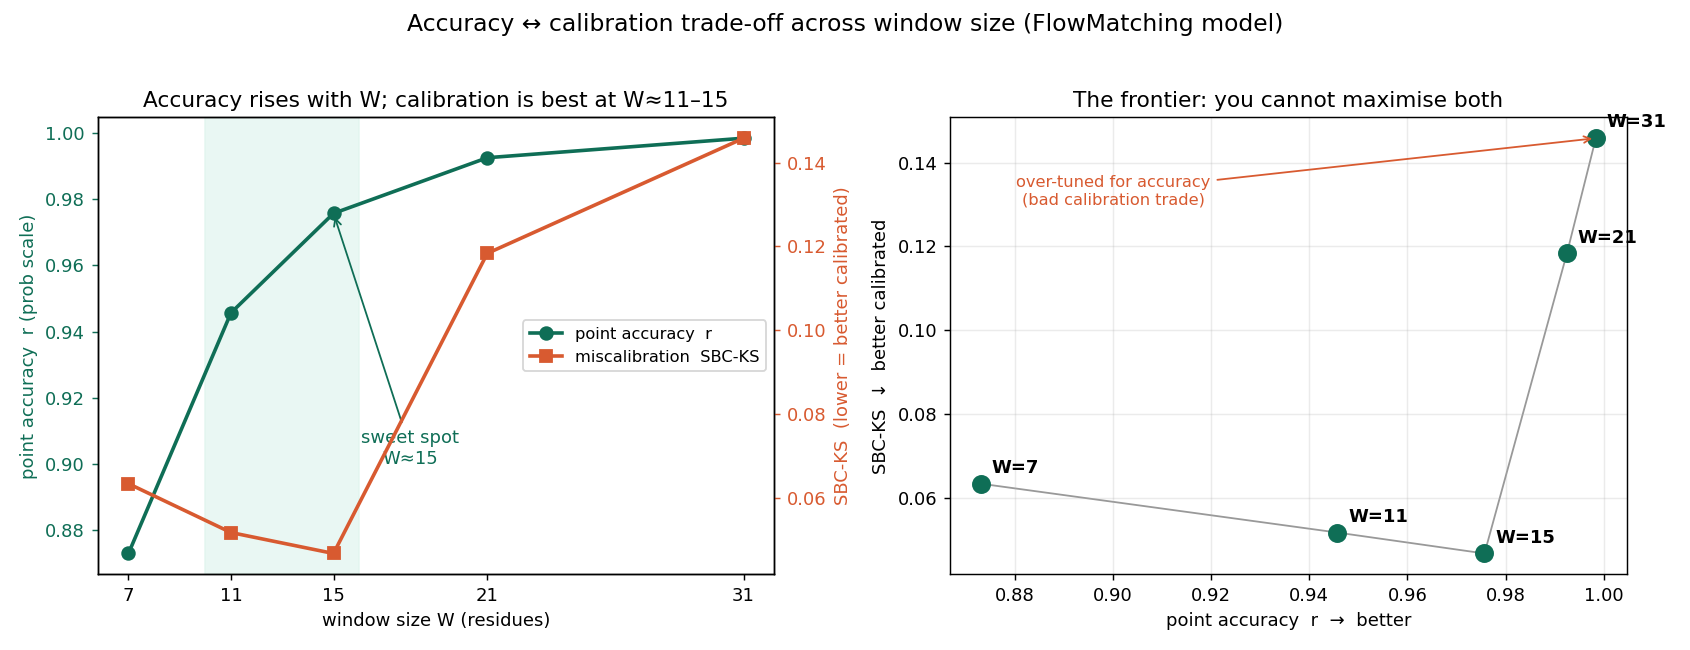

In [18]:
display(Image(filename="figures/pareto_frontier.png"))

## Step 7 — Known issues / red flags

Being explicit about what is *not* clean:

1. **SBC calibration bias.** The rank ECDF exits the 95% band. The posterior *width* is right
   (mean|z| ≈ 0.8), but the *location* is off by ~0.15 posterior SD (≈0.002 in probability).
   Point estimates are unaffected (r = 0.999) — only a sensitive test like SBC catches it.
2. **The logit-clip atom (fixed).** γ₀ = 0 *exactly* for every chain (start rule) — the only atom
   in 24.3M residues. `logit` clipped it to −6.907: a point mass a continuous flow cannot represent,
   which also inflated the standardisation sd of `prev`/`centre` by 13%/7% while leaving `next`
   untouched — **exactly** the dims that show a positive SBC bias. `build_training_data` now drops
   the first 2 positions (`SKIP_START=2`), where γ is known a priori anyway.
3. **Near-degenerate target.** The 3 target dims correlate 0.89–0.96, so the true joint is nearly a
   1-D curve in 3-D — awkward for a *coupling* flow, which splits dimensions.
4. **No summary network.** The 31×21 window is flattened to 651 and fed straight in. A 1D-CNN
   summary net is the canonical BayesFlow choice; deferred.
5. **Insulin rests on 2 chains.** Illustrative, not a benchmark.

In [19]:
# Red flag 2, measured: the clip atom and its effect on standardisation.
tr2, _ = load_chains(list(range(0, 2000)))
c2 = [tr2[i] for i in range(2000)]
for skip, label in [(0, "old (atoms present)"), (2, "now (SKIP_START=2)")]:
    t = np.asarray(build_training_data(c2, 40000, np.random.default_rng(7),
                                       skip_start=skip)["theta"], np.float32)
    atoms = [(t[:, i] < -6.9).sum() for i in range(3)]
    sds = [f"{t[:, i].std():.3f}" for i in range(3)]
    print(f"{label:22s} atoms(prev/centre/next)={atoms}   sd={sds}")
print("\n-> dropping the deterministic start residues removes the atom and matches the sds.")

old (atoms present)    atoms(prev/centre/next)=[np.int64(520), np.int64(273), np.int64(0)]   sd=['1.422', '1.348', '1.260']


now (SKIP_START=2)     atoms(prev/centre/next)=[np.int64(0), np.int64(0), np.int64(0)]   sd=['1.261', '1.249', '1.244']

-> dropping the deterministic start residues removes the atom and matches the sds.


## TL;DR

- α-helix as a **2-state HMM** whose transition **and emission** tables match real proteins (r ≈ 0.99).
- **BayesFlow** amortized posterior trained on exact **Forward–Backward** targets via a sliding **31-residue window**; reproduces exact FB almost perfectly (**r = 0.999**).
- **Diagnostics:** excellent recovery & contraction, but SBC shows a small (~0.15 SD) calibration bias — an owned limitation.
- On unseen real proteins it ranks **propensity-driven** helices well (insulin B-chain 0.98; PISCES 0.75) but **fails where structure is 3-D-stabilised** (insulin A-chain 0.52) — the price of a sequence-only model. Exact FB is a ceiling on *simulated* data only.